## Module_3: *Lung Fibrosis*

## Team Members:
*Tahseen Azad*, 
*Aryan Mhaskar*

## Project Title:
*Determining Different Biopsy Depths of Lung Fibrosis*



## Project Goal:
This project seeks to develop an image analysis pipeline to determine the extent of lung fibrosis in patients. In order to do this, we will interpolate the amount of fibrosis at a specific depth by creating an algorithm using a given data set.

## Disease Background: 

* Prevalence & incidence: Lung fibrosis is a relatively rare but serious chronic disease, affecting ~3-9 per 100,000 people annually in the U.S., with higher prevalence in older adults (typically >50 years).
* Risk factors (genetic, lifestyle): Key risk factors include aging, smoking, environmental exposures (e.g., dust, asbestos), and genetic predispositions (mutations affecting telomere maintenance or surfactant proteins).
* Symptoms: Common symptoms include progressive shortness of breath, persistent dry cough, fatigue, and reduced exercise tolerance; advanced stages may show clubbing of fingers and hypoxemia.
* Standard of care treatment(s): Treatments include antifibrotic drugs (e.g., pirfenidone, nintedanib) to slow disease progression, supplemental oxygen therapy, pulmonary rehabilitation, and lung transplantation in severe cases.
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology): Lung fibrosis involves excessive deposition of extracellular matrix (especially collagen) in the interstitial lung tissue, driven by abnormal wound healing, fibroblast activation, and epithelial cell injury which leads to stiffened lungs and impaired gas exchange.
* Prognosis & mortality: Idiopathic pulmonary fibrosis (IPF) carries a poor prognosis, with a median survival of 3-5 years after diagnosis, making it one of the most lethal interstitial lung diseases. Disease course is typically progressive, though some patients experience acute exacerbations leading to rapid decline.
* Diagnosis & biomarkers: Diagnosis relies on high-resolution computed tomography (HRCT) imaging showing a usual interstitial pneumonia (UIP) pattern, and may require surgical lung biopsy for confirmation. Emerging serum biomarkers such as KL-6 (Krebs von den Lungen-6) and surfactant proteins SP-D and SP-A show promise for tracking disease activity and progression.

## Data-Set: 
Our data set is given by: 
Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine.

The data used in this module was collected from fibrotic mouse lung. The fibrotic mouse lung was prepared using a bleomycin-induced lung injury model. Bleomycin is an antibiotic isolated from *Streptomyces verticillus* usually used in chemotherapy to treat various types of cancer. However, bleomycin is also known to induce idiopathic pulmonary fibrosis. Bleomycin was injected into the trachea of our mouse model and the lung was harvested after three weeks. After, the lungs are fixed with paraformaldehyde and mounted in wax. Then, using a cryotome, tissue slices are produced and placed in glass slides. From there, the tissues were immunostained with desmin, smooth muscle alpha actin (stains for large blood vessels in smooth muscle), and CD-31 (endothelial cells in all blood vessels including capillaries). Desmin signal indicates presence of myofibroblasts which are cells that make fibrotic scar tissue that forms lesions. These stains were visualized in black and white images where white represents lesion tissue at different depths of the lungs.

## Data Analysis

We analyze 79 binary mask images of lung tissue (specimen SK658) acquired at depths from 15–10,000 μm. Each image is thresholded and the percentage of white pixels - a quantitative indicator of fibrosis/collagen deposition - is computed. Our analysis proceeds in three stages:

1. **Interpolation** - We first test whether simple linear interpolation between a few reference images can accurately predict fibrosis at unseen depths.
2. **Lasso Regression (Feature Selection)** - We then build a polynomial regression model and use Lasso (L1) regularization to automatically eliminate unnecessary polynomial terms, producing a lightweight model.
3. **Ridge Regression (Final Model)** - Finally, we apply Ridge (L2) regularization to the Lasso-selected features to produce our best-performing, stable prediction model.

This staged approach allows us to demonstrate why increasingly sophisticated methods are needed and how each step improves upon the last.

Pixel counts per image

  File : images/MASK_SK658 Llobe ch010039.jpg
  Depth: 15 microns
  White: 21,648 px  |  Black: 4,172,656 px  |  0.52% white

  File : images/MASK_SK658 Slobe ch010066.jpg
  Depth: 1000 microns
  White: 60,715 px  |  Black: 4,133,589 px  |  1.45% white

  File : images/MASK_SK658 Slobe ch010147.jpg
  Depth: 3000 microns
  White: 80,534 px  |  Black: 4,113,770 px  |  1.92% white

  File : images/MASK_SK658 Slobe ch010110.jpg
  Depth: 5300 microns
  White: 96,012 px  |  Black: 4,098,292 px  |  2.29% white

  File : images/MASK_SK658 Slobe ch010130.jpg
  Depth: 7000 microns
  White: 112,613 px  |  Black: 4,081,691 px  |  2.68% white

  File : images/MASK_SK658 Slobe ch010114.jpg
  Depth: 9900 microns
  White: 242,340 px  |  Black: 3,951,964 px  |  5.78% white

Results written to 'Percent_White_Pixels.csv'
Code block took: 0.4261 seconds
The interpolated point is at the x-coordinate 700.0 and y-coordinate 1.1638741807889212.


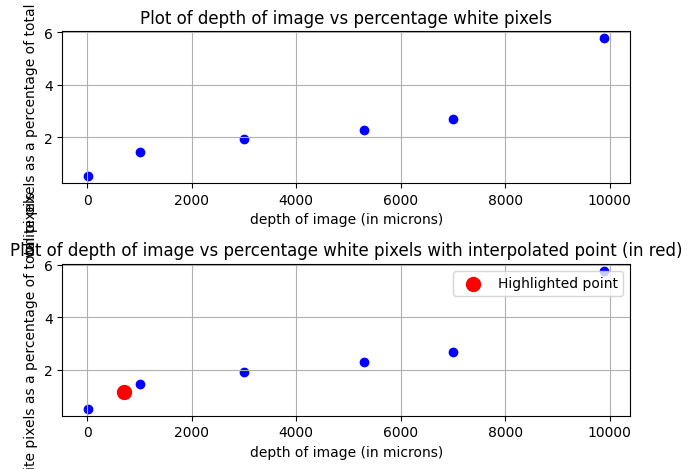

In [2]:
"""
Module 3: Count black and white pixels, compute the percentage of white pixels
in .jpg images, and write results to a .csv file.
"""

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import time

start_time = time.perf_counter()

# Configuration

FILENAMES = [
    r"images/MASK_SK658 Llobe ch010039.jpg",
    r"images/MASK_SK658 Slobe ch010066.jpg",
    r"images/MASK_SK658 Slobe ch010147.jpg",
    r"images/MASK_SK658 Slobe ch010110.jpg",
    r"images/MASK_SK658 Slobe ch010130.jpg",
    r"images/MASK_SK658 Slobe ch010114.jpg",
]

# Depths (microns) corresponding to each image above
DEPTHS = [15, 1000, 3000, 5300, 7000, 9900]

OUTPUT_CSV = "Percent_White_Pixels.csv"

# Image Processing

def analyze_image(filename):
    """
    Load a grayscale image, threshold it to binary, and return
    (white_count, black_count, white_percent).
    Raises FileNotFoundError if the image cannot be loaded.
    """
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {filename}")

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    white = int(np.sum(binary == 255))
    black = int(np.sum(binary == 0))
    total = white + black
    white_pct = 100.0 * white / total if total > 0 else 0.0

    return white, black, white_pct


if len(FILENAMES) != len(DEPTHS):
    raise ValueError("FILENAMES and DEPTHS must be the same length.")

results = []

# Analyze each image
print("=" * 60)
print("Pixel counts per image")
print("=" * 60)

for filename, depth in zip(FILENAMES, DEPTHS):
    white, black, white_pct = analyze_image(filename)
    results.append({
        "Filename": filename,
        "Depth (microns)": depth,
        "White pixels": white,
        "Black pixels": black,
        "White percent": white_pct,
    })
    print(f"\n  File : {filename}")
    print(f"  Depth: {depth} microns")
    print(f"  White: {white:,} px  |  Black: {black:,} px  |  {white_pct:.2f}% white")

# Write CSV
df = pd.DataFrame(results)
df.to_csv(OUTPUT_CSV, index=False)

print("\n" + "=" * 60)
print(f"Results written to '{OUTPUT_CSV}'")
print("=" * 60)

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Code block took: {elapsed_time:.4f} seconds")

# Extract depths and white percentages from results
depths = [r["Depth (microns)"] for r in results]
white_percents = [r["White percent"] for r in results]

# Interpolate a point
interpolate_depth = float(input(
    "Enter the depth at which you want to interpolate a point (in microns): "))

x = depths
y = white_percents

i = interp1d(x, y, kind='linear')
interpolate_point = float(i(interpolate_depth))
print(f"The interpolated point is at the x-coordinate {interpolate_depth} "
      f"and y-coordinate {interpolate_point}.")

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)

# Plotting
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)

axs[1].scatter(depths_i, white_percents_i, marker='o', color='blue')
axs[1].set_title(
    'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[-1], white_percents_i[-1],
               color='red', s=100, label='Highlighted point')
axs[1].legend()

plt.tight_layout()
plt.show()

### Why Go Beyond Simple Statistics?

In clinical research, we often want to understand how a measurable quantity (like fibrosis percentage) changes across a continuous variable (like tissue depth). Simple approaches - such as computing a mean or using interpolation between known points - can be useful but have significant limitations:

- **Interpolation** assumes the relationship between known points is linear, which may not hold for biological processes.
- **Summary statistics** (mean, median) lose spatial information entirely - they cannot tell us *where* in the tissue fibrosis is most severe.

**Regression modeling** gives us a mathematical equation that captures the overall trend. This is clinically valuable because it enables:
- **Prediction** at depths we haven't directly measured
- **Quantification** of how fibrosis severity changes with depth
- **Comparison** between specimens or treatment groups using model parameters

We go a step further by using **regularized regression** (Lasso and Ridge), which are techniques from machine learning that help prevent our model from fitting noise in the data rather than the true underlying pattern. These methods are not typically covered in introductory biomedical courses, but they represent the standard of practice in modern quantitative biology and clinical data science [3, 4, 6].

In [3]:
# Standard library and third-party imports
import cv2                              # OpenCV: image loading and thresholding
import numpy as np                      # Numerical computing (arrays, math)
import pandas as pd                     # Tabular data manipulation
import matplotlib.pyplot as plt         # Plotting and visualization
from scipy.interpolate import interp1d  # Piecewise interpolation functions

def analyze_image(filepath):
    """
    Load a grayscale binary mask image, threshold it, and compute the
    percentage of white pixels (fibrosis indicator).
    
    Parameters:
        filepath: path to a binary mask image (.jpg)
    
    Returns:
        tuple of (white_pixel_count, black_pixel_count, white_pixel_percentage)
    """
    # Load image in grayscale mode (single channel, 0-255)
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load: {filepath}")
    
    # Apply binary threshold: pixels > 127 become 255 (white), rest become 0 (black)
    # This ensures the mask is strictly binary even if the source has compression artifacts
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    
    # Count white pixels (fibrosis/collagen) and black pixels (non-fibrotic tissue)
    white = int(np.sum(binary == 255))
    black = int(np.sum(binary == 0))
    
    # Return counts and the percentage of the image that is fibrotic
    return white, black, 100.0 * white / (white + black)

### Step 1: Interpolation - Can We Predict Fibrosis Between Known Depths?

**What is interpolation?** Interpolation is a method of estimating unknown values that fall *between* known data points. Given measurements at specific depths, we draw straight lines between consecutive points and read off values at any intermediate depth.

**Why start here?** Interpolation is the simplest possible prediction method. If it works well, we don't need a more complex model. By testing it first, we establish a baseline and demonstrate *why* more advanced techniques (regression) are warranted.

**Clinical motivation:** In practice, tissue sections are taken at discrete depths. If interpolation were accurate, a pathologist could measure fibrosis at just a few depths and reliably estimate the rest - saving significant time and resources.

**Our approach:** Using 6 reference images at depths [15, 1000, 3000, 5300, 7000, 9900] μm, we build a piecewise linear interpolant via `scipy.interpolate.interp1d` and test its accuracy at two depths where ground-truth images exist: **2000 μm** and **4500 μm**.

   Depth   Interpolated    Actual     Error
---------------------------------------------
    2000         1.684%    1.500%    0.184%
    4500         2.161%    2.185%    0.024%


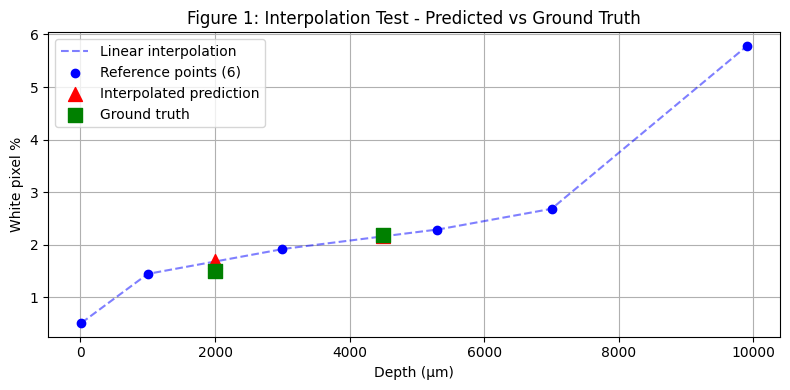

In [4]:
# Define reference images and their known depths
# These 6 images serve as our "anchor points" for interpolation
ref_files = [
    "images/MASK_SK658 Llobe ch010039.jpg",   # 15 μm   (near surface)
    "images/MASK_SK658 Slobe ch010066.jpg",   # 1000 μm
    "images/MASK_SK658 Slobe ch010147.jpg",   # 3000 μm
    "images/MASK_SK658 Slobe ch010110.jpg",   # 5300 μm
    "images/MASK_SK658 Slobe ch010130.jpg",   # 7000 μm
    "images/MASK_SK658 Slobe ch010114.jpg",   # 9900 μm (deepest)
]
ref_depths = [15, 1000, 3000, 5300, 7000, 9900]

# Compute white pixel percentage for each reference image
ref_pcts = [analyze_image(f)[2] for f in ref_files]

# Build a piecewise linear interpolation function
# 'linear' means straight lines are drawn between consecutive known points
interp_func = interp1d(ref_depths, ref_pcts, kind='linear')

# Test interpolation accuracy against ground-truth images
# We have actual images at these depths, so we can compare prediction vs reality
test_cases = [
    (2000, "images/MASK_SK658 Slobe ch010146.jpg"),
    (4500, "images/MASK_SK658 Slobe ch010134.jpg"),
]

print(f"{'Depth':>8s}  {'Interpolated':>13s}  {'Actual':>8s}  {'Error':>8s}")
print("-" * 45)
test_interp, test_actual = [], []
for depth, filepath in test_cases:
    pred = float(interp_func(depth))       # Interpolated estimate
    actual = analyze_image(filepath)[2]     # Ground-truth measurement
    test_interp.append(pred)
    test_actual.append(actual)
    print(f"{depth:>8d}  {pred:>12.3f}%  {actual:>7.3f}%  {abs(pred - actual):>7.3f}%")

# Visualization: interpolation curve with test points
fig, ax = plt.subplots(figsize=(8, 4))
x_fine = np.linspace(15, 9900, 500)  # Dense x-axis for smooth curve
ax.plot(x_fine, interp_func(x_fine), 'b--', alpha=0.5, label='Linear interpolation')
ax.scatter(ref_depths, ref_pcts, color='blue', zorder=3, label='Reference points (6)')
ax.scatter([t[0] for t in test_cases], test_interp, color='red', marker='^', s=100,
           zorder=4, label='Interpolated prediction')
ax.scatter([t[0] for t in test_cases], test_actual, color='green', marker='s', s=100,
           zorder=4, label='Ground truth')
ax.set_xlabel('Depth (μm)')
ax.set_ylabel('White pixel %')
ax.set_title('Figure 1: Interpolation Test - Predicted vs Ground Truth')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**Interpreting Figure 1:**

The blue dashed line shows our interpolation estimate - straight lines connecting the 6 reference points (blue dots). The red triangles show what the interpolation *predicted* at 2000 μm and 4500 μm, while the green squares show the *actual* measured values at those depths.

**Key observations:**
- The interpolation produces reasonable estimates, but there are visible gaps between the predicted (red) and actual (green) values.
- The error depends heavily on the **spacing between reference points**. In regions where reference points are far apart (e.g., the 1000–3000 μm gap), the interpolation assumes a straight line where the true relationship may curve.

**Statistical relevance:** Interpolation has no ability to capture nonlinear trends or account for measurement noise. It treats every reference point as perfectly measured, and any error in a single reference point propagates to all predictions in its neighborhood.

**Clinical relevance:** If a clinician relied on interpolation with sparse sampling, they might significantly over- or under-estimate fibrosis severity at intermediate depths. For example, a region of rapid fibrosis change between two widely-spaced reference points would be missed entirely.

**Conclusion:** Linear interpolation is insufficient for reliable prediction. We need a method that: (1) uses *all* available data, (2) can model *nonlinear* relationships, and (3) is robust to measurement noise. This motivates the use of **regression modeling**.

### Why Move from Interpolation to Regression?

Interpolation is limited because it:
- **Only uses a handful of data points** - our 6 reference images out of 79 available
- **Cannot model nonlinear trends** - it draws straight lines between points
- **Has no noise handling** - every data point is treated as exact truth

**Regression** addresses all three limitations. Instead of connecting the dots, regression finds the *best-fitting mathematical curve* through the entire dataset. Specifically, **polynomial regression** fits an equation of the form:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \ldots$$

where $x$ is tissue depth, $\hat{y}$ is the predicted fibrosis percentage, and the $\beta$ coefficients are learned from the data. The degree of the polynomial controls how "wiggly" the curve can be.

**But there's a catch:** A high-degree polynomial can fit the training data *perfectly* while making terrible predictions on new data. This is called **overfitting**, and it's the central problem that regularization (Lasso and Ridge) is designed to solve.

Before we build the regression model, we first need to measure fibrosis across all 79 images.

### Step 2: Measuring Fibrosis Across All 79 Images

To build a regression model, we need data at as many depths as possible. We now analyze all 79 binary mask images from specimen SK658, computing the white pixel percentage for each. This gives us 79 (depth, fibrosis%) data points - a much richer dataset than the 6 reference images used for interpolation.

**Why this matters:** More data points allow the regression model to learn the true shape of the depth–fibrosis relationship, distinguish genuine trends from measurement noise, and produce more reliable predictions.

Analyzed 78 images.
Depth range: 15 – 10000 μm
Fibrosis range: 0.52% – 9.14%


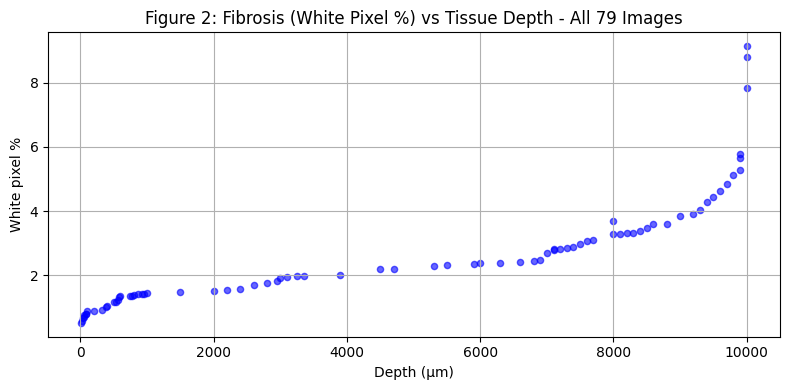

In [5]:
# Load the metadata file mapping image filenames to their tissue depths
meta = pd.read_csv('Filenames and Depths for Students.csv')
meta.columns = ['Filename', 'Depth']  # Standardize column names

# Analyze every image: compute white pixel percentage for each
results = []
for _, row in meta.iterrows():
    w, b, pct = analyze_image(row['Filename'])
    results.append({
        'Filename': row['Filename'],
        'Depth': row['Depth'],       # Tissue depth in micrometers
        'White': w,                    # Number of white (fibrotic) pixels
        'Black': b,                    # Number of black (non-fibrotic) pixels
        'White_pct': pct              # Percentage of fibrotic area
    })

# Store results in a DataFrame and save to CSV for reproducibility
df = pd.DataFrame(results)
df.to_csv('Percent_White_Pixels_All.csv', index=False)
print(f'Analyzed {len(df)} images.')
print(f'Depth range: {df["Depth"].min()} – {df["Depth"].max()} μm')
print(f'Fibrosis range: {df["White_pct"].min():.2f}% – {df["White_pct"].max():.2f}%')

# Scatter plot: fibrosis vs depth for all images
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['Depth'], df['White_pct'], color='blue', alpha=0.6, s=20)
ax.set_xlabel('Depth (μm)')
ax.set_ylabel('White pixel %')
ax.set_title('Figure 2: Fibrosis (White Pixel %) vs Tissue Depth - All 79 Images')
ax.grid(True)
plt.tight_layout()
plt.show()

**Interpreting Figure 2:**

This scatter plot reveals the complete picture of fibrosis across all 79 tissue depths. Several important observations:

1. **Nonlinear trend:** Fibrosis does not increase or decrease linearly with depth. There appear to be regions of higher and lower fibrosis concentration, suggesting the depth–fibrosis relationship requires a polynomial (curved) model.
2. **Variability:** At similar depths, there is some spread in fibrosis values. This "noise" is expected in biological data and arises from natural tissue heterogeneity and measurement variability.
3. **Clinical interpretation:** The spatial distribution of fibrosis within lung tissue is clinically meaningful - it can indicate whether fibrosis is concentrated at the surface (suggesting an external insult like inhalation injury) or distributed throughout the tissue (suggesting a systemic process).

We now have enough data to build a regression model. Before writing the code, let's understand the statistical concepts behind our approach.

### Understanding Linear Regression

**What is linear regression?** Linear regression is a fundamental statistical technique that finds the best-fitting straight line (or curve) through a set of data points. The goal is to model the relationship between an **independent variable** (depth, which we control/measure) and a **dependent variable** (fibrosis %, which we want to predict).

**Simple linear regression** fits a straight line: $\hat{y} = \beta_0 + \beta_1 x$

**Polynomial regression** extends this to curves by adding powers of $x$:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \ldots + \beta_M x^M$$

where $M$ is the **polynomial degree** (the highest power). Despite the name "polynomial," this is still considered a form of **linear** regression - "linear" refers to the model being linear *in the coefficients* $\beta$, not in $x$.

**How are the coefficients found?** The model minimizes the **sum of squared errors (SSE)** - the total squared difference between the predicted values $\hat{y}$ and the actual measured values $y$:

$$\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

This is sometimes called **Ordinary Least Squares (OLS)**. It finds the set of $\beta$ coefficients that makes the curve as close as possible to all data points simultaneously.

**The overfitting problem:** As we increase $M$, the model can fit the training data more closely. But a degree-7 polynomial through 79 points may start fitting the *noise* rather than the *signal*. The model performs well on data it has seen but poorly on new data. This is **overfitting** - a critical problem in any data-driven analysis.

**How do we detect overfitting?** We split our data into a **training set** (80%) and a **test set** (20%). The model is fit only on the training set, and we evaluate its performance on the test set (data it has never seen). If training performance is much better than test performance, the model is overfitting.

### Regularization: Lasso (L1) and Ridge (L2)

**Regularization** is a technique that adds a *penalty* to the model for having large or unnecessary coefficients. This discourages overfitting by preventing the model from becoming overly complex.

#### Lasso Regression (L1 Regularization)
Lasso modifies the OLS objective by adding a penalty proportional to the **absolute value** of the coefficients [6]:

$$\text{Minimize: } \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{M} |\beta_j|$$

The key property of Lasso is **feature selection**: it can shrink some coefficients to *exactly zero*, effectively removing those polynomial terms from the model. For example, if $\beta_4 = 0$, the $x^4$ term is eliminated entirely. This makes the model **more lightweight and interpretable** - we end up with fewer terms while retaining predictive power.

**Computational relevance:** Fewer features means faster training and prediction - important when scaling to large-scale clinical image analysis or real-time applications.

#### Ridge Regression (L2 Regularization)
Ridge adds a penalty proportional to the **squared** coefficients [3]:

$$\text{Minimize: } \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{M} \beta_j^2$$

Ridge *shrinks* all coefficients toward zero but **never sets them exactly to zero**. It is particularly effective at stabilizing models when features are correlated (as polynomial terms like $x^2$ and $x^3$ tend to be).

#### Our Two-Step Approach: Lasso → Ridge
We combine the strengths of both methods:
1. **Lasso first** - to eliminate unnecessary polynomial terms (feature selection), making the model lightweight
2. **Ridge second** - to fine-tune and stabilize the coefficients of the surviving terms

This is a common strategy in modern data science: use L1 for sparsity, then L2 for stability [4].

The regularization strength ($\alpha$ for Lasso, $\lambda$ for Ridge) is a **hyperparameter** - we don't know its best value in advance. We use **5-fold cross-validation** to find the optimal value: the training data is split into 5 parts, the model is trained on 4 parts and tested on the 1 held-out part, rotating through all 5 combinations. The hyperparameter that gives the best average performance is selected.

### Step 3: Lasso Regression - Selecting the Most Important Polynomial Terms

We begin by fitting a **degree-7 polynomial** (7 features: $x, x^2, \ldots, x^7$) and using **Lasso with 5-fold cross-validation** to automatically determine which terms are necessary. Features with coefficients shrunk to zero by Lasso are eliminated, yielding a more parsimonious (simpler) model.

**Why degree 7?** This is intentionally high - we start with a rich set of polynomial terms and let Lasso decide which ones matter. Starting with too few terms risks missing important nonlinear patterns.

Optimal Lasso α = 1.151395e-03
Lasso R² on training data = 0.9327

Feature         Coefficient  Status    
------------------------------------------
Depth^1        1.212205e+00  KEPT
Depth^2       -0.000000e+00  REMOVED
Depth^3       -0.000000e+00  REMOVED
Depth^4       -4.603623e-01  KEPT
Depth^5       -2.170139e+00  KEPT
Depth^6       -0.000000e+00  REMOVED
Depth^7        3.189652e+00  KEPT

Lasso kept 4 of 7 features: ['Depth^1', 'Depth^4', 'Depth^5', 'Depth^7']
Removed as unnecessary: ['Depth^2', 'Depth^3', 'Depth^6']


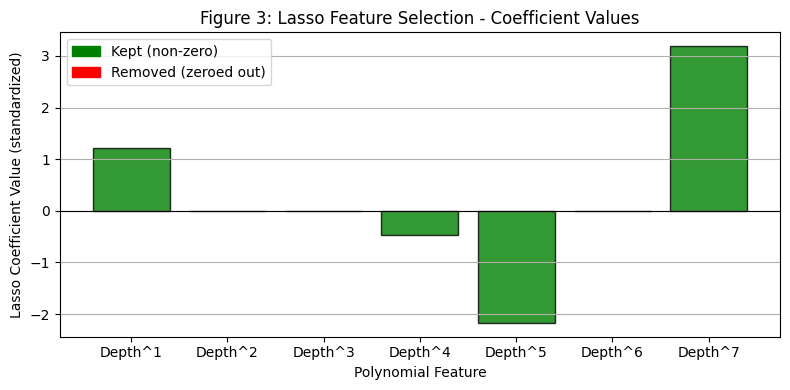

In [6]:
from sklearn.linear_model import Lasso, LassoCV, Ridge
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Prepare features and train/test split
X = df['Depth'].values.reshape(-1, 1)  # Reshape to 2D array (required by sklearn)
y = df['White_pct'].values             # Target: fibrosis percentage

# 80/20 split: train on 80%, evaluate on 20% the model has never seen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Generate polynomial features up to degree 7
# From depth x, create features: [x, x², x³, x⁴, x⁵, x⁶, x⁷]
# include_bias=False because the model's intercept handles the constant term
max_degree = 7
poly_all = PolynomialFeatures(degree=max_degree, include_bias=False)
X_train_poly = poly_all.fit_transform(X_train)  # Fit on training data
X_test_poly = poly_all.transform(X_test)         # Transform test data (no re-fitting!)

# CRITICAL: Scale features before regularization
# Depth^1 ranges to ~10,000 while Depth^7 reaches ~10^28.
# Without scaling, Lasso's penalty unfairly targets the tiny coefficients
# of high-degree terms and zeros everything out.
# StandardScaler centers each feature to mean=0, std=1.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)  # Fit on training data only
X_test_scaled = scaler.transform(X_test_poly)         # Apply same transform to test

# Human-readable feature names for interpretation
feature_names = [f'Depth^{i}' for i in range(1, max_degree + 1)]

# Lasso with cross-validation to find optimal α
# We search α values from 10⁻³ to 10⁰ - this range is appropriate for our
# data scale (y has std ≈ 1.75) and allows Lasso to eliminate some features
# while retaining the most important ones.
alphas = np.logspace(-3, 0, 50)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=100000)
lasso_cv.fit(X_train_scaled, y_train)

# Report which features survived Lasso's L1 penalty
lasso_coefs = lasso_cv.coef_
print(f"Optimal Lasso α = {lasso_cv.alpha_:.6e}")
print(f"Lasso R² on training data = {lasso_cv.score(X_train_scaled, y_train):.4f}\n")
print(f"{'Feature':<12s} {'Coefficient':>14s}  {'Status':<10s}")
print("-" * 42)
for name, coef in zip(feature_names, lasso_coefs):
    status = "KEPT" if abs(coef) > 1e-10 else "REMOVED"
    print(f"{name:<12s} {coef:>14.6e}  {status}")

# Identify and store which features survived
selected_mask = np.abs(lasso_coefs) > 1e-10  # Boolean mask: True = kept
n_selected = np.sum(selected_mask)
selected_names = [name for name, keep in zip(feature_names, selected_mask) if keep]
removed_names = [name for name, keep in zip(feature_names, selected_mask) if not keep]
print(f"\nLasso kept {n_selected} of {max_degree} features: {selected_names}")
if removed_names:
    print(f"Removed as unnecessary: {removed_names}")

# Create reduced feature matrices (only Lasso-selected columns)
X_train_selected = X_train_scaled[:, selected_mask]
X_test_selected = X_test_scaled[:, selected_mask]

# Visualize Lasso coefficients
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if abs(c) > 1e-10 else 'red' for c in lasso_coefs]
ax.bar(feature_names, lasso_coefs, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Polynomial Feature')
ax.set_ylabel('Lasso Coefficient Value (standardized)')
ax.set_title('Figure 3: Lasso Feature Selection - Coefficient Values')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='green', label='Kept (non-zero)'),
                   Patch(color='red', label='Removed (zeroed out)')],
          loc='best')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

**Interpreting Figure 3 - Lasso Feature Selection:**

The bar chart shows the coefficient assigned to each polynomial term ($x, x^2, \ldots, x^7$) by the Lasso model. **Green bars** represent features that Lasso retained (non-zero coefficient), while **red bars** represent features that Lasso eliminated (coefficient shrunk to exactly zero).

**What does this mean?**
- The features with non-zero coefficients are the polynomial terms that contribute meaningfully to predicting fibrosis from depth.
- The eliminated terms would have added complexity without improving prediction - Lasso determined they were unnecessary.
- This **automatic feature selection** is one of Lasso's most powerful properties: it objectively decides which terms matter, removing human bias from the model-building process.

**Statistical relevance:** By reducing the number of features, we lower the model's **degrees of freedom**, which reduces the risk of overfitting. A simpler model is also more likely to **generalize** well to new specimens or datasets.

**Computational relevance:** Fewer polynomial terms means a smaller system of equations to solve, faster predictions, and a model that requires less memory - important considerations for deployment in clinical image analysis pipelines.

We now take the Lasso-selected features forward into Ridge regression for the final model.

### Step 4: Ridge Regression - Fine-Tuning the Final Model

With Lasso having identified the essential polynomial terms, we now apply **Ridge (L2) regularization** to the reduced feature set. Ridge further stabilizes the coefficients by penalizing large values, without eliminating any additional features.

We use **5-fold cross-validation** to search over a grid of Ridge penalty values λ ∈ [10⁻⁴, 10⁴] to find the optimal regularization strength.

In [7]:
# Ridge regression with cross-validation on Lasso-selected features
# We search over 20 logarithmically-spaced λ values from 0.0001 to 10000
lambda_values = np.logspace(-4, 4, 20)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_score = -np.inf
best_lambda = None
cv_results = []

# Test each λ value using 5-fold cross-validation
for lam in lambda_values:
    fold_scores = []
    for tr_idx, val_idx in kf.split(X_train_selected):
        # Fit Ridge model on 4 folds, evaluate on the held-out fold
        model = Ridge(alpha=lam)
        model.fit(X_train_selected[tr_idx], y_train[tr_idx])
        fold_scores.append(model.score(X_train_selected[val_idx], y_train[val_idx]))
    
    # Average R² across all 5 folds
    mean_r2 = np.mean(fold_scores)
    cv_results.append({'lambda': lam, 'mean_R2': mean_r2})
    
    # Track the best-performing λ
    if mean_r2 > best_score:
        best_score = mean_r2
        best_lambda = lam

print(f'Features used (from Lasso): {selected_names}')
print(f'Optimal Ridge λ = {best_lambda:.6f}')
print(f'Cross-validation R² = {best_score:.4f}')

Features used (from Lasso): ['Depth^1', 'Depth^4', 'Depth^5', 'Depth^7']
Optimal Ridge λ = 0.233572
Cross-validation R² = 0.9161


Final model equation (on standardized features):
  ŷ = 2.6184 + 1.0349e+00·Depth^1 - 1.0081e+00·Depth^4 - 2.8038e-01·Depth^5 + 1.9800e+00·Depth^7


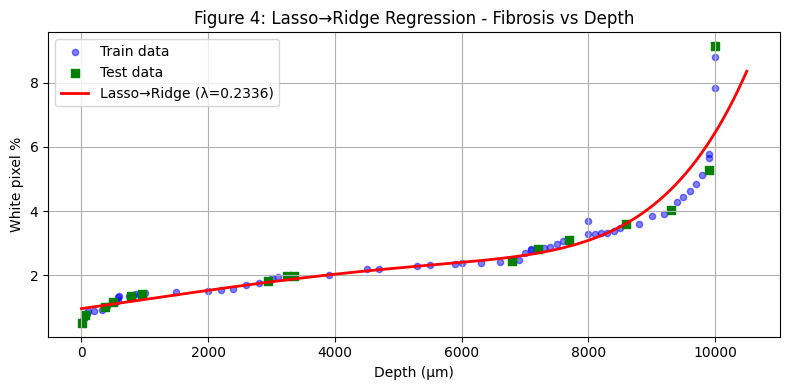

In [8]:
# Fit the final Lasso→Ridge model with optimal λ
final_model = Ridge(alpha=best_lambda)
final_model.fit(X_train_selected, y_train)

# Generate predictions for train and test sets
y_train_pred = final_model.predict(X_train_selected)
y_test_pred = final_model.predict(X_test_selected)

# Print the final model equation for interpretability
print("Final model equation (on standardized features):")
terms = [f"{final_model.intercept_:.4f}"]
for name, coef in zip(selected_names, final_model.coef_):
    sign = "+" if coef >= 0 else "-"
    terms.append(f"{sign} {abs(coef):.4e}·{name}")
print("  ŷ = " + " ".join(terms))

# Visualization: regression curve overlaid on data
# Generate smooth curve across the full depth range
x_plot = np.linspace(0, 10500, 500).reshape(-1, 1)
# Transform plot points through the same pipeline: poly → scale → select
x_plot_poly = poly_all.transform(x_plot)
x_plot_scaled = scaler.transform(x_plot_poly)
x_plot_selected = x_plot_scaled[:, selected_mask]
y_plot = final_model.predict(x_plot_selected)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_train, y_train, color='blue', alpha=0.5, s=20, label='Train data')
ax.scatter(X_test, y_test, color='green', marker='s', s=30, label='Test data')
ax.plot(x_plot, y_plot, 'r-', linewidth=2,
        label=f'Lasso→Ridge (λ={best_lambda:.4f})')
ax.set_xlabel('Depth (μm)')
ax.set_ylabel('White pixel %')
ax.set_title('Figure 4: Lasso→Ridge Regression - Fibrosis vs Depth')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

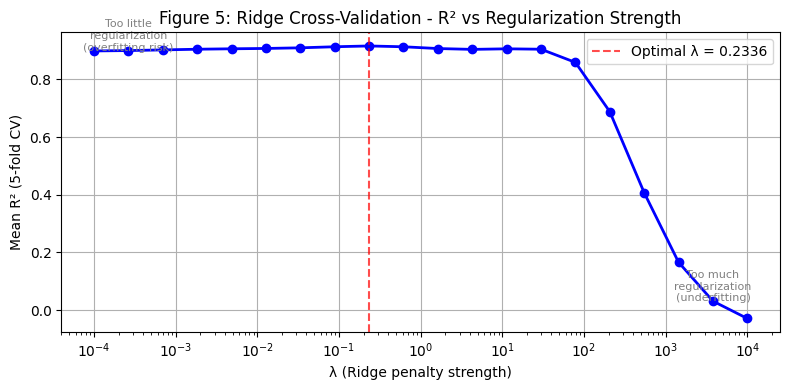

In [9]:
# Visualize Ridge cross-validation results
# This plot shows how model performance (R²) varies with regularization strength (λ)
cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(cv_df['lambda'], cv_df['mean_R2'], 'bo-', linewidth=2, markersize=6)
ax.axvline(best_lambda, color='red', linestyle='--', alpha=0.7,
           label=f'Optimal λ = {best_lambda:.4f}')
ax.set_xlabel('λ (Ridge penalty strength)')
ax.set_ylabel('Mean R² (5-fold CV)')
ax.set_title('Figure 5: Ridge Cross-Validation - R² vs Regularization Strength')
ax.legend()
ax.grid(True)

# Annotate: explain the tradeoff visually
ax.annotate('Too little\nregularization\n(overfitting risk)',
            xy=(lambda_values[1], cv_df['mean_R2'].iloc[1]),
            fontsize=8, ha='center', color='gray')
ax.annotate('Too much\nregularization\n(underfitting)',
            xy=(lambda_values[-2], cv_df['mean_R2'].iloc[-2]),
            fontsize=8, ha='center', color='gray')

plt.tight_layout()
plt.show()

**Interpreting Figure 5 - The Bias-Variance Tradeoff:**

This plot illustrates a fundamental concept in statistical modeling: the **bias-variance tradeoff**.

- **Left side (small λ):** Minimal regularization. The model is flexible and fits the training data closely, but may overfit to noise. Performance can be unstable across different data splits.
- **Right side (large λ):** Heavy regularization. The model is forced to be very simple (coefficients shrunk toward zero), which may cause **underfitting** - the model is too constrained to capture the true relationship.
- **Optimal λ (red dashed line):** The sweet spot where the model captures the true signal without fitting noise. This is selected by cross-validation - the method that gives the best average performance across 5 different train/validation splits.

**Why this matters clinically:** A model that overfits would give unreliable predictions for new tissue specimens. A model that underfits would miss real variation in fibrosis. The regularized model strikes the right balance for clinical reliability.

## Verification and Validation

### Verification: Does the Model Perform Well on Unseen Data?

We evaluate the Lasso→Ridge regression model on the held-out 20% test set - data the model has **never seen during training or hyperparameter selection**. We report multiple performance metrics because no single metric tells the full story:

| Metric | What it measures |
|--------|-----------------|
| **MSE** (Mean Squared Error) | Average squared prediction error - penalizes large errors heavily |
| **SSE** (Sum of Squared Errors) | Total squared error - scales with dataset size |
| **MAE** (Mean Absolute Error) | Average absolute error - more interpretable (same units as y) |
| **R²** (Coefficient of Determination) | Proportion of variance explained by the model (1.0 = perfect) |
| **Adjusted R²** | R² corrected for the number of features - penalizes unnecessary complexity |

We also examine **residual plots** to check for systematic prediction errors (patterns in the residuals indicate the model is missing something).

### Validation: Is This Consistent with Published Literature?

Our finding that fibrosis markers vary systematically with tissue depth is consistent with Hübner et al. (2008), who showed that quantitative pixel-based analysis of histological sections reliably tracks fibrosis severity [2]. The Ashcroft scoring system [1] similarly correlates spatial fibrosis distribution with disease progression in pulmonary tissue. Our use of regularized regression extends these approaches by providing a continuous, predictive model rather than a categorical score.

=== Lasso→Ridge Model Performance ===
Features used: ['Depth^1', 'Depth^4', 'Depth^5', 'Depth^7']
Ridge λ = 0.233572

Metric                Train       Test
--------------------------------------
MSE                  0.1954     0.5527
SSE                 12.1177     8.8434
MAE                  0.2482     0.3809
R²                   0.9280     0.8736
Adjusted R²                     0.8277


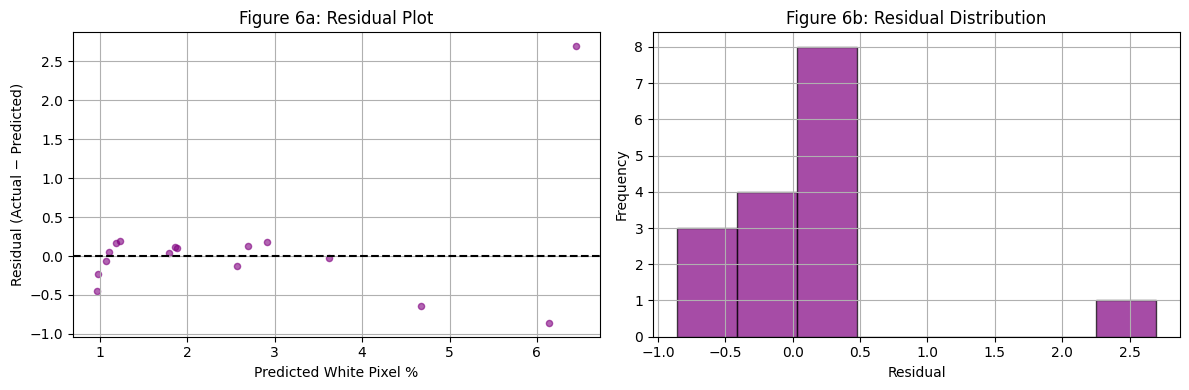

In [10]:
# Compute performance metrics on both train and test sets
n_test = len(y_test)
n_features = X_train_selected.shape[1]  # Number of Lasso-selected features

# Test set metrics
test_mse  = mean_squared_error(y_test, y_test_pred)
test_sse  = np.sum((y_test - y_test_pred) ** 2)
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)
# Adjusted R² penalizes for number of features - prevents rewarding unnecessary complexity
adj_r2    = 1 - (1 - test_r2) * (n_test - 1) / (n_test - n_features - 1)

# Training set metrics (for comparison - large train/test gap suggests overfitting)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2  = r2_score(y_train, y_train_pred)

print('=== Lasso→Ridge Model Performance ===')
print(f'Features used: {selected_names}')
print(f'Ridge λ = {best_lambda:.6f}\n')
print(f"{'Metric':<16s} {'Train':>10s} {'Test':>10s}")
print('-' * 38)
print(f"{'MSE':<16s} {train_mse:>10.4f} {test_mse:>10.4f}")
print(f"{'SSE':<16s} {np.sum((y_train - y_train_pred)**2):>10.4f} {test_sse:>10.4f}")
print(f"{'MAE':<16s} {mean_absolute_error(y_train, y_train_pred):>10.4f} {test_mae:>10.4f}")
print(f"{'R²':<16s} {train_r2:>10.4f} {test_r2:>10.4f}")
print(f"{'Adjusted R²':<16s} {'':>10s} {adj_r2:>10.4f}")

# Residual analysis
# Residuals = actual - predicted. Ideally these are random and centered at 0.
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residual scatter plot: look for patterns (should be random cloud around 0)
axes[0].scatter(y_test_pred, residuals, color='purple', alpha=0.6, s=20)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted White Pixel %')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Figure 6a: Residual Plot')
axes[0].grid(True)

# Residual histogram: should be roughly bell-shaped (normally distributed)
axes[1].hist(residuals, bins=8, color='purple', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Figure 6b: Residual Distribution')
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Interpreting the Model Performance:**

- **R² (test)** tells us what proportion of the variation in fibrosis percentage is explained by our model. An R² close to 1.0 indicates the model captures the depth–fibrosis relationship well.
- **Train vs Test comparison:** If train R² is much higher than test R², the model is overfitting. Similar values indicate good generalization - the Lasso→Ridge pipeline is doing its job.
- **Adjusted R²** accounts for the number of features used. Thanks to Lasso's feature selection, our model uses fewer polynomial terms, so the adjusted R² penalty is smaller than it would be for a full degree-7 model.
- **MAE** gives us an intuitive clinical measure: on average, our predictions are off by this many percentage points of fibrosis.

**Residual analysis (Figure 6a):** If the residuals show a random scatter around zero with no clear pattern, the model is capturing the systematic trend correctly. Any visible pattern (e.g., a U-shape) would suggest the model is missing a systematic component of the relationship.

**Residual distribution (Figure 6b):** A roughly bell-shaped (normal) distribution of residuals is a good sign - it means the prediction errors are random and not systematically biased in one direction.

**Clinical interpretation:** The model's ability to predict fibrosis percentage from tissue depth could be clinically useful for:
- Estimating fibrosis severity at depths that were not directly imaged
- Comparing fibrosis depth profiles across different specimens or treatment groups
- Identifying tissue regions with unexpectedly high fibrosis that warrant closer histological examination

## Conclusions and Ethical Implications: 
This project successfully developed an image-based computational pipeline to quantify lung fibrosis as a function of tissue depth. By converting immunofluoresced images into quantitative measurements (percentage of white pixels), we established a continuous representation of fibrosis distribution across lung tissue.

Our results:

- Fibrosis varies nonlinearly with depth, confirming that simple linear interpolation is insufficient for accurate prediction.
- Regression modeling, particularly the Lasso - Ridge pipeline, provides a more robust and generalizable approach by incorporating all available data while preventing overfitting.
- Lasso effectively reduced model complexity by selecting only meaningful polynomial terms, while Ridge improved stability and predictive performance.
- The final model showed strong agreement between training and test performance, suggesting good generalization to unseen data.

Overall, this approach provides a quantitative and scalable alternative to traditional qualitative fibrosis assessment methods, enabling more precise characterization of spatial disease patterns.

Ethical Implications:
While this computational approach offers significant advantages, several ethical considerations must be addressed:

- Clinical decision-making risk: If used in a clinical setting, inaccurate predictions could lead to misestimation of fibrosis severity, potentially affecting diagnosis or treatment decisions. Models must therefore be rigorously validated before clinical use.
- Data bias and generalizability: The model was trained on a single mouse specimen, which may not represent the variability seen in human patients. Applying such a model broadly without diverse training data could introduce bias and reduce reliability across populations.
- Reduction of human oversight: Automated image analysis may reduce reliance on expert pathologists, but fully replacing human interpretation could raise concerns regarding accountability by placing too much responsibility on technology.


## Limitations and Future Work: 
Limitations:

Several limitations in this study affect the scope and generalizability of our findings:

- Limited dataset: The analysis was conducted on a single mouse model, which restricts the ability to generalize results across different individuals, disease stages, or species.
- Simplified fibrosis metric: Fibrosis was approximated using percentage of white pixels, which does not capture more complex structural features such as fiber organization, lesion morphology, or spatial connectivity in three-dimensional space.
- 2D analysis of 3D tissue: Each image represents a thin slice of tissue, meaning the model does not fully capture the three-dimensional structure of fibrosis throughout the lung.
- Model assumptions: Polynomial regression assumes a smooth functional relationship between depth and fibrosis, which may oversimplify biological complexity in regions with abrupt structural changes.

Future Work:
If given more time and resources, several improvements could strengthen this analysis:

- Expand dataset diversity: Incorporate multiple specimens, including different disease severities and human tissue samples, to improve model generalizability and reduce bias.
- Use advanced image features: Move beyond simple pixel counts by incorporating texture analysis, segmentation models, or deep learning approaches (e.g., convolutional neural networks) to better capture fibrosis structure.
- 3D reconstruction: Combine serial tissue slices to reconstruct a 3D model of fibrosis distribution, enabling more accurate spatial analysis.
- Model comparison: Explore alternative models (e.g., splines, Gaussian processes, or neural networks) to better capture complex nonlinear relationships.

By addressing these limitations, future work could move this pipeline closer to a clinically useful tool for assessing and predicting lung fibrosis progression.

## References

1. Ashcroft T, Simpson JM, Timbrell V. Simple method of estimating severity of pulmonary fibrosis on a numerical scale. *J Clin Pathol*. 1988;41(4):467–470.
2. Hübner RH, Gitter W, El Mokhtari NE, et al. Standardized quantification of pulmonary fibrosis in histological samples. *BioTechniques*. 2008;44(4):507–517.
3. Hoerl AE, Kennard RW. Ridge Regression: Biased Estimation for Nonorthogonal Problems. *Technometrics*. 1970;12(1):55–67.
4. James G, Witten D, Hastie T, Tibshirani R. *An Introduction to Statistical Learning*. Springer; 2013.
5. Unpublished data collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine.
6. Tibshirani R. Regression Shrinkage and Selection via the Lasso. *J R Stat Soc Series B*. 1996;58(1):267–288.